# Ancillary Services Data Analysis
## Price Forecasting and Response Time Modeling

This notebook demonstrates:
1. Loading processed data
2. Exploratory data analysis
3. Feature importance analysis
4. Baseline forecasting models
5. Response time analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Import custom modules
from data_processing import AncillaryServicesFeatureEngineer
import config

# Plotting settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## 1. Load Processed Data

In [3]:
# Initialize feature engineer
engineer = AncillaryServicesFeatureEngineer(
    data_dir=config.OUTPUT_DIR
)

# Create master dataset
master_df = engineer.create_master_dataset()
print(f"Master dataset shape: {master_df.shape}")
print(f"Date range: {master_df.index.min()} to {master_df.index.max()}")
master_df.head()

Master dataset shape: (180045, 21)
Date range: 2021-01-01 00:00:00+01:00 to 2026-05-02 23:45:00+02:00


,"balancing_price_('Down', 1, 'Activated')","balancing_price_('Down', 1, 'Offered')","balancing_price_('Up', 2, 'Activated')","balancing_price_('Up', 2, 'Offered')","balancing_price_('Down', 3, 'Activated')","balancing_price_('Down', 3, 'Offered')","balancing_price_('Up', 4, 'Activated')","balancing_price_('Up', 4, 'Offered')",imbalance_price_Long,imbalance_price_Short,...,generation_Hydro Run-of-river and poundage,generation_Hydro Water Reservoir,generation_Nuclear,generation_Solar,generation_Wind Onshore,load,flow_DE,flow_FR,flow_AT,flow_IT
2021-01-01 00:00:00+01:00,9.45,0.0,69.25,0.0,NaN,NaN,NaN,NaN,32.2,78.3,...,145.25,276.53,3004.7,0.0,14.31,7360.61,NaN,NaN,NaN,NaN
2021-01-01 00:15:00+01:00,2.01,0.0,10.94,0.0,NaN,NaN,NaN,NaN,32.2,78.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-01 00:30:00+01:00,2.54,0.0,1.16,0.0,NaN,NaN,NaN,NaN,32.2,78.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-01 00:45:00+01:00,10.38,0.0,0.69,0.0,NaN,NaN,NaN,NaN,32.2,78.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-01 01:00:00+01:00,0.03,0.0,124.79,0.0,NaN,NaN,NaN,NaN,28.6,71.6,...,116.15,253.05,3006.0,0.0,14.80,7460.32,NaN,NaN,NaN,NaN


## 2. Data Quality Check

Missing Data Percentage:
flow_AT                                       100.000000
flow_IT                                        99.906690
flow_FR                                        99.906690
flow_DE                                        99.906690
balancing_price_('Down', 3, 'Activated')       99.583993
balancing_price_('Down', 3, 'Offered')         99.583993
balancing_price_('Up', 4, 'Activated')         99.578439
balancing_price_('Up', 4, 'Offered')           99.578439
load                                           74.999583
generation_Nuclear                             74.997917
generation_Wind Onshore                        74.997917
generation_Solar                               74.997917
generation_Hydro Pumped Storage                74.997917
generation_Hydro Water Reservoir               74.997917
generation_Hydro Run-of-river and poundage     74.997917
balancing_price_('Down', 1, 'Offered')          2.541587
balancing_price_('Down', 1, 'Activated')        2.541587
balanc

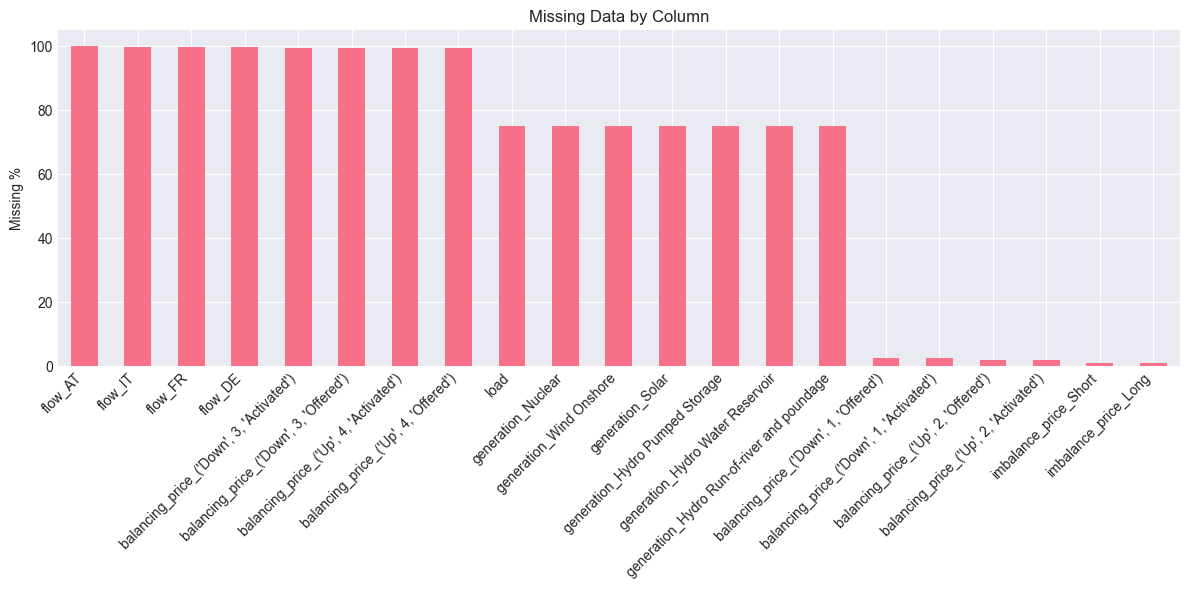

In [4]:
# Check for missing values
missing_pct = (master_df.isnull().sum() / len(master_df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print("Missing Data Percentage:")
print(missing_pct)

# Plot missing data
if len(missing_pct) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    missing_pct.plot(kind='bar', ax=ax)
    ax.set_ylabel('Missing %')
    ax.set_title('Missing Data by Column')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 3. Balancing Price Analysis

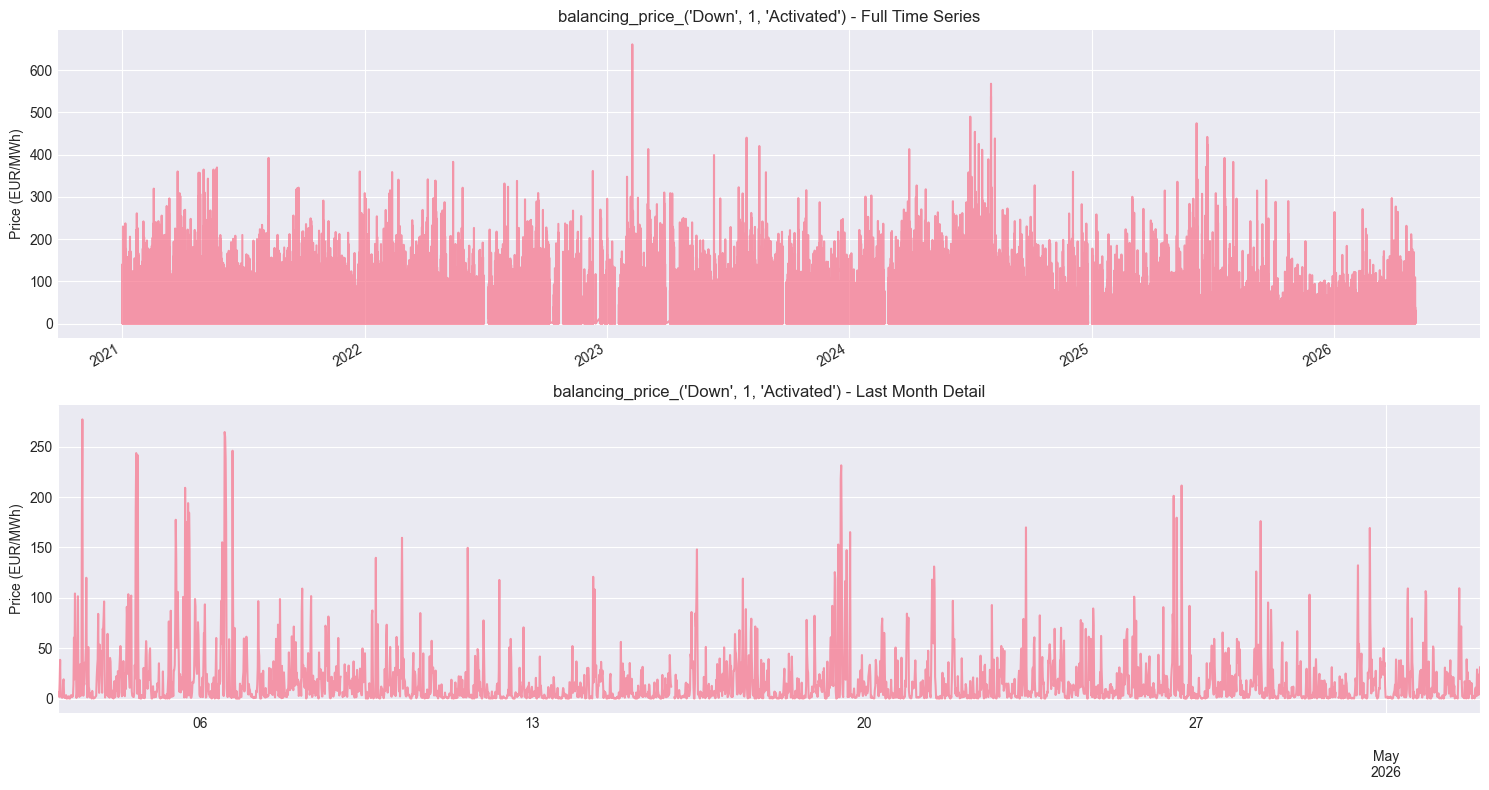


Summary Statistics for balancing_price_('Down', 1, 'Activated'):
count    175469.000000
mean         17.617756
std          33.106301
min           0.000000
25%           1.237000
50%           4.140000
75%          17.973000
max         661.010000
Name: balancing_price_('Down', 1, 'Activated'), dtype: float64


In [5]:
# Identify balancing price columns
price_cols = [col for col in master_df.columns if 'balancing_price' in col.lower()]

if price_cols:
    # Select first price column for analysis
    price_col = price_cols[0]
    
    # Time series plot
    fig, axes = plt.subplots(2, 1, figsize=(15, 8))
    
    # Full time series
    master_df[price_col].plot(ax=axes[0], alpha=0.7)
    axes[0].set_title(f'{price_col} - Full Time Series')
    axes[0].set_ylabel('Price (EUR/MWh)')
    
    # Recent month detail
    recent = master_df[price_col].iloc[-2880:]  # Last month (15-min data)
    recent.plot(ax=axes[1], alpha=0.7)
    axes[1].set_title(f'{price_col} - Last Month Detail')
    axes[1].set_ylabel('Price (EUR/MWh)')
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print(f"\nSummary Statistics for {price_col}:")
    print(master_df[price_col].describe())

## 4. Temporal Patterns in Prices

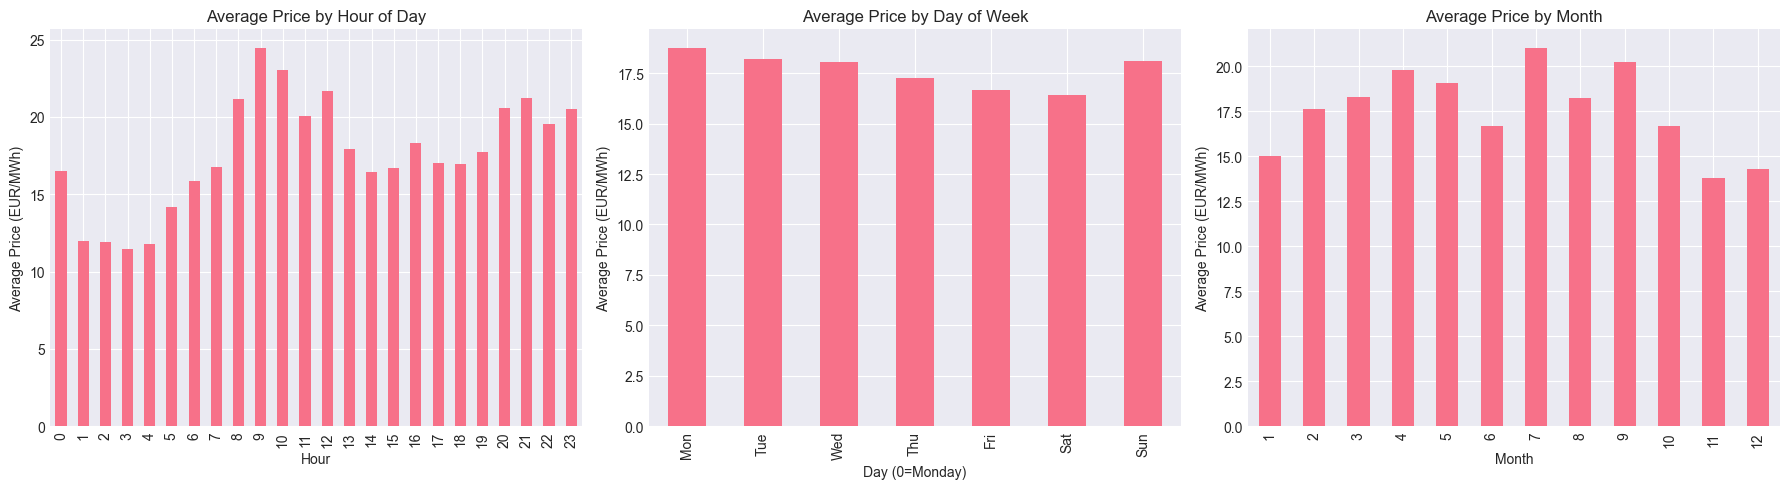

In [6]:
if price_cols:
    price_col = price_cols[0]
    
    # Add temporal features for analysis
    df_temp = master_df[[price_col]].copy()
    df_temp['hour'] = df_temp.index.hour
    df_temp['day_of_week'] = df_temp.index.dayofweek
    df_temp['month'] = df_temp.index.month
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Hourly pattern
    hourly_avg = df_temp.groupby('hour')[price_col].mean()
    hourly_avg.plot(kind='bar', ax=axes[0])
    axes[0].set_title('Average Price by Hour of Day')
    axes[0].set_xlabel('Hour')
    axes[0].set_ylabel('Average Price (EUR/MWh)')
    
    # Day of week pattern
    dow_avg = df_temp.groupby('day_of_week')[price_col].mean()
    dow_avg.plot(kind='bar', ax=axes[1])
    axes[1].set_title('Average Price by Day of Week')
    axes[1].set_xlabel('Day (0=Monday)')
    axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    axes[1].set_ylabel('Average Price (EUR/MWh)')
    
    # Monthly pattern
    monthly_avg = df_temp.groupby('month')[price_col].mean()
    monthly_avg.plot(kind='bar', ax=axes[2])
    axes[2].set_title('Average Price by Month')
    axes[2].set_xlabel('Month')
    axes[2].set_ylabel('Average Price (EUR/MWh)')
    
    plt.tight_layout()
    plt.show()

## 5. Price Volatility Analysis

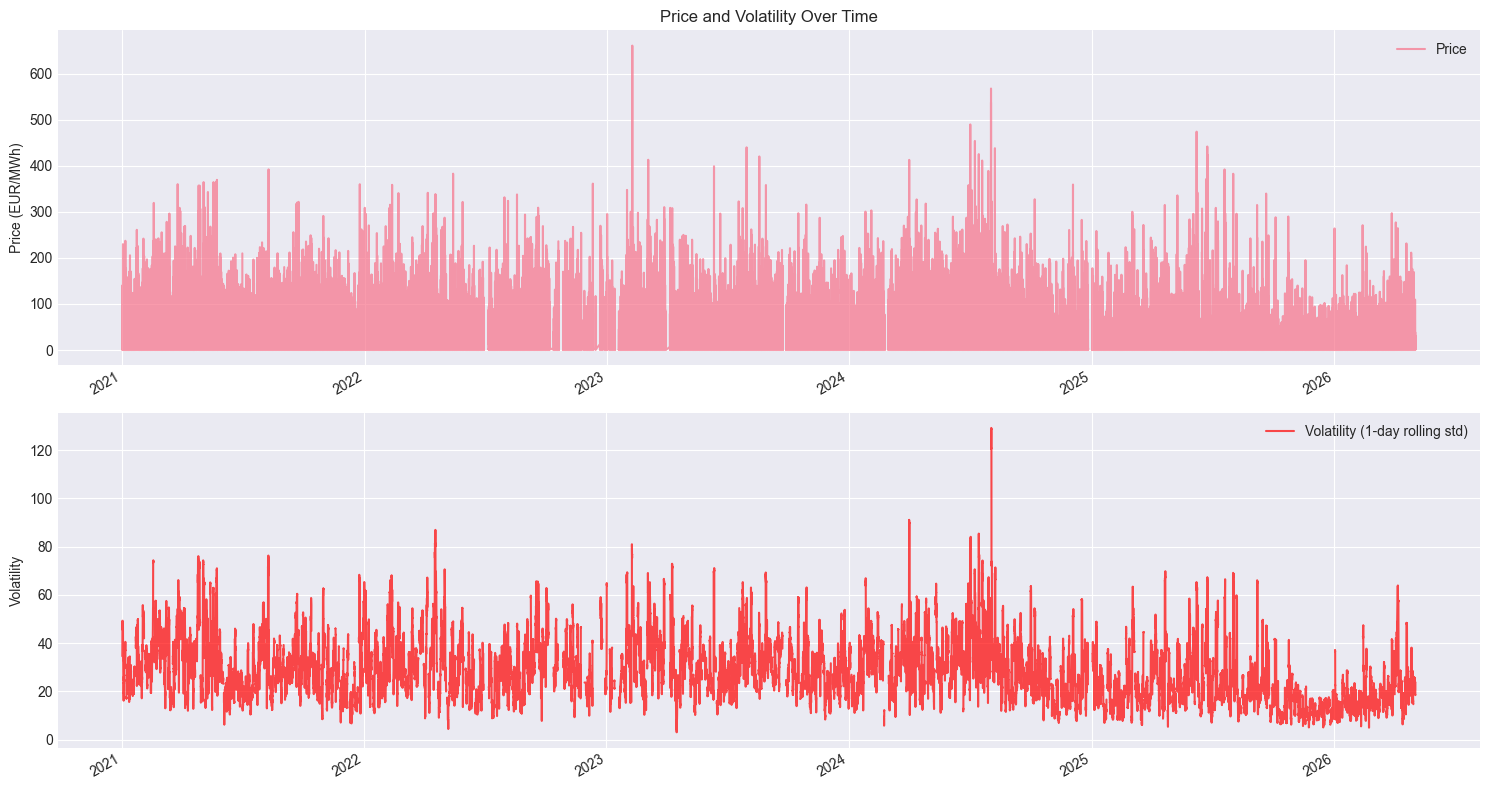


Price spike threshold (95th percentile): 84.20 EUR/MWh
Number of price spikes: 8774 (4.87%)


In [7]:
if price_cols:
    price_col = price_cols[0]
    
    # Calculate rolling volatility (standard deviation)
    volatility = master_df[price_col].rolling(window=96).std()  # 1-day rolling window
    
    fig, axes = plt.subplots(2, 1, figsize=(15, 8))
    
    # Price and volatility
    master_df[price_col].plot(ax=axes[0], alpha=0.7, label='Price')
    axes[0].set_ylabel('Price (EUR/MWh)')
    axes[0].set_title('Price and Volatility Over Time')
    axes[0].legend()
    
    volatility.plot(ax=axes[1], alpha=0.7, color='red', label='Volatility (1-day rolling std)')
    axes[1].set_ylabel('Volatility')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Identify price spikes
    threshold = master_df[price_col].quantile(0.95)
    spikes = master_df[master_df[price_col] > threshold]
    print(f"\nPrice spike threshold (95th percentile): {threshold:.2f} EUR/MWh")
    print(f"Number of price spikes: {len(spikes)} ({len(spikes)/len(master_df)*100:.2f}%)")

## 6. Reserve Capacity Analysis

In [8]:
# Check for reserve data
reserve_cols = [col for col in master_df.columns if any(r in col for r in ['FCR', 'aFRR', 'mFRR'])]

if reserve_cols:
    print("Available reserve columns:")
    for col in reserve_cols[:10]:  # Show first 10
        print(f"  - {col}")
    
    # Plot reserve trends if available
    fcr_cols = [col for col in reserve_cols if 'FCR' in col]
    afrr_cols = [col for col in reserve_cols if 'aFRR' in col]
    mfrr_cols = [col for col in reserve_cols if 'mFRR' in col]
    
    if fcr_cols or afrr_cols or mfrr_cols:
        fig, ax = plt.subplots(figsize=(15, 6))
        
        if fcr_cols:
            master_df[fcr_cols[0]].plot(ax=ax, label='FCR', alpha=0.7)
        if afrr_cols:
            master_df[afrr_cols[0]].plot(ax=ax, label='aFRR', alpha=0.7)
        if mfrr_cols:
            master_df[mfrr_cols[0]].plot(ax=ax, label='mFRR', alpha=0.7)
        
        ax.set_title('Reserve Capacity Over Time')
        ax.set_ylabel('Capacity (MW)')
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print("No reserve data available in master dataset")

No reserve data available in master dataset


## 7. Correlation Analysis

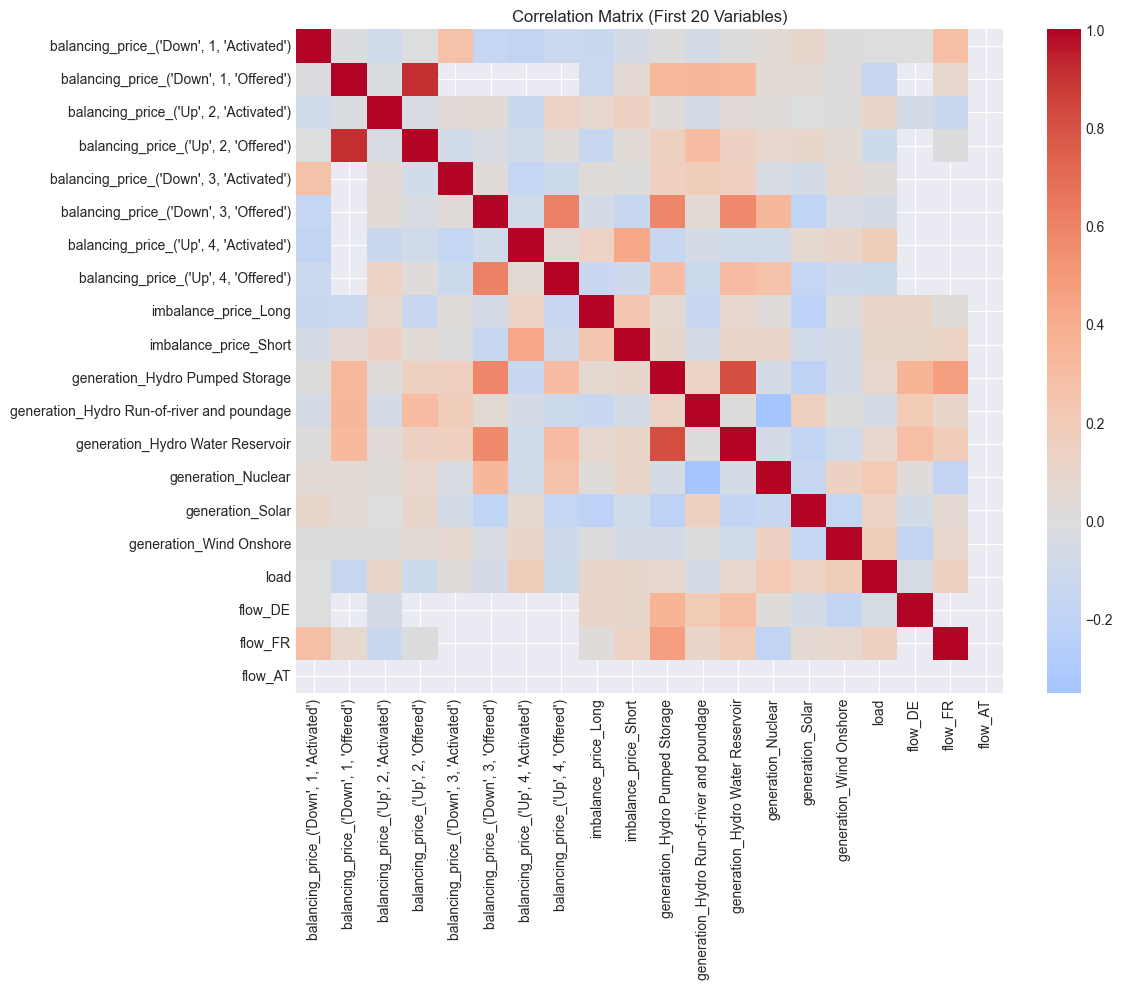


Top 10 correlations with balancing_price_('Down', 1, 'Activated'):
flow_FR                                       0.292073
balancing_price_('Down', 3, 'Activated')      0.269105
balancing_price_('Up', 4, 'Activated')        0.192700
balancing_price_('Down', 3, 'Offered')        0.169690
imbalance_price_Long                          0.130473
balancing_price_('Up', 4, 'Offered')          0.125255
balancing_price_('Up', 2, 'Activated')        0.096674
generation_Solar                              0.091978
imbalance_price_Short                         0.053212
generation_Hydro Run-of-river and poundage    0.050905
Name: balancing_price_('Down', 1, 'Activated'), dtype: float64


In [9]:
# Select numerical columns for correlation
numerical_cols = master_df.select_dtypes(include=[np.number]).columns.tolist()

# Limit to first 20 columns if too many
if len(numerical_cols) > 20:
    numerical_cols = numerical_cols[:20]

# Calculate correlation matrix
corr_matrix = master_df[numerical_cols].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix (First 20 Variables)')
plt.tight_layout()
plt.show()

# Print highest correlations with balancing price
if price_cols:
    price_col = price_cols[0]
    if price_col in numerical_cols:
        price_corr = corr_matrix[price_col].abs().sort_values(ascending=False)
        print(f"\nTop 10 correlations with {price_col}:")
        print(price_corr[1:11])  # Exclude self-correlation

## 8. Baseline Forecasting Model

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Prepare forecasting dataset
if price_cols:
    price_col = price_cols[0]
    
    print(f"Preparing forecasting dataset for {price_col}...")
    X, y = engineer.prepare_forecasting_dataset(
        target_col=price_col,
        forecast_horizon=4  # 1 hour ahead
    )
    
    print(f"Features shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False  # No shuffle for time series
    )
    
    # Baseline: Random Forest
    print("\nTraining Random Forest baseline model...")
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    
    # Predictions
    y_pred_train = rf.predict(X_train)
    y_pred_test = rf.predict(X_test)
    
    # Metrics
    print("\n=== Model Performance ===")
    print("\nTraining Set:")
    print(f"  MAE: {mean_absolute_error(y_train, y_pred_train):.2f}")
    print(f"  RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
    print(f"  R²: {r2_score(y_train, y_pred_train):.4f}")
    
    print("\nTest Set:")
    print(f"  MAE: {mean_absolute_error(y_test, y_pred_test):.2f}")
    print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
    print(f"  R²: {r2_score(y_test, y_pred_test):.4f}")

Preparing forecasting dataset for balancing_price_('Down', 1, 'Activated')...


/Users/johan/MasterThesisProjects/ENTSOE-Claude/data_processing.py:236: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_lag_{lag}'] = df[col].shift(lag)
/Users/johan/MasterThesisProjects/ENTSOE-Claude/data_processing.py:236: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_lag_{lag}'] = df[col].shift(lag)
/Users/johan/MasterThesisProjects/ENTSOE-Claude/data_processing.py:236: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfo

Features shape: (0, 398)
Target shape: (0,)


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

## 9. Feature Importance

In [12]:
if price_cols:
    # Get feature importances
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Plot top 20 features
    fig, ax = plt.subplots(figsize=(10, 8))
    feature_importance.head(20).plot(
        x='feature', 
        y='importance', 
        kind='barh', 
        ax=ax
    )
    ax.set_title('Top 20 Feature Importances')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))

NameError: name 'X_train' is not defined

## 10. Prediction Visualization

NameError: name 'y_test' is not defined

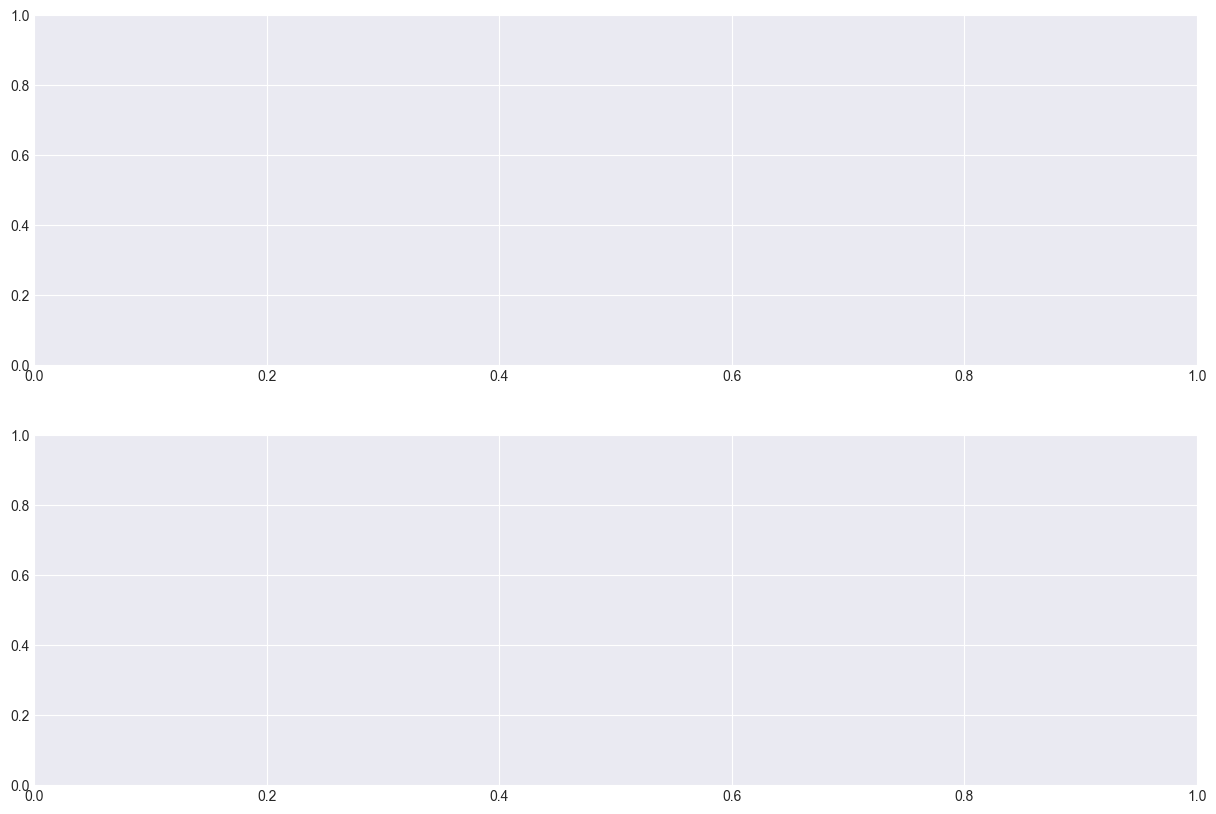

In [13]:
if price_cols:
    # Plot actual vs predicted for test set
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))
    
    # Time series comparison
    test_index = y_test.index
    axes[0].plot(test_index, y_test.values, label='Actual', alpha=0.7)
    axes[0].plot(test_index, y_pred_test, label='Predicted', alpha=0.7)
    axes[0].set_title('Actual vs Predicted Prices (Test Set)')
    axes[0].set_ylabel('Price (EUR/MWh)')
    axes[0].legend()
    
    # Scatter plot
    axes[1].scatter(y_test.values, y_pred_test, alpha=0.3)
    axes[1].plot([y_test.min(), y_test.max()], 
                 [y_test.min(), y_test.max()], 
                 'r--', lw=2, label='Perfect Prediction')
    axes[1].set_xlabel('Actual Price')
    axes[1].set_ylabel('Predicted Price')
    axes[1].set_title('Prediction Scatter Plot')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

## Next Steps for Your Thesis

1. **Advanced Models**: Try LSTM, XGBoost, LightGBM for better performance
2. **Hyperparameter Tuning**: Use GridSearchCV or Optuna
3. **Response Time Modeling**: Analyze activation patterns by reserve type
4. **Causality Analysis**: Granger causality tests
5. **Regime Detection**: Hidden Markov Models for market states
6. **Ensemble Methods**: Combine multiple forecasting approaches
7. **External Data**: Weather, spot prices, etc.
8. **Real-time Updates**: Online learning framework